<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/Pratica3Quest%C3%A3o1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

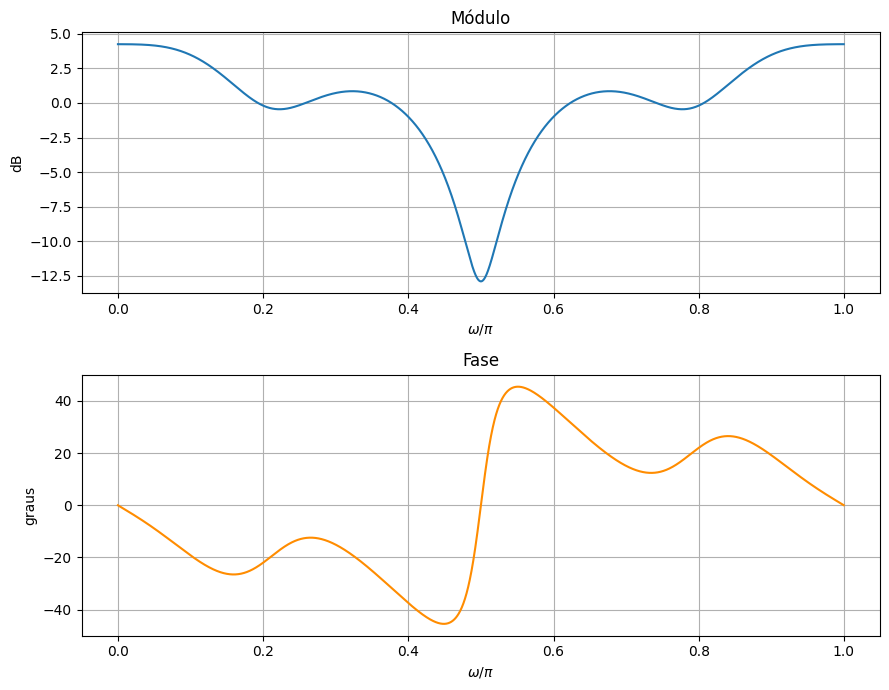

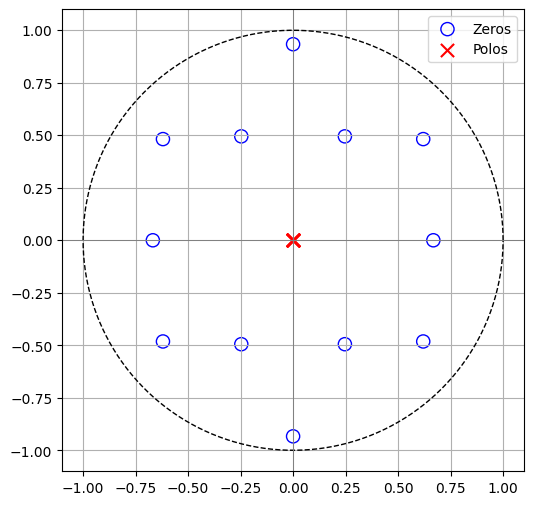

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- 1. Coeficientes de H(z) ---
# H(z) = 1 + 0.49 z^-2 + 0.2401 z^-6 - 0.0576 z^-8 - 0.0282 z^-10 - 0.0138 z^-12
b = np.zeros(13)
b[0]  = 1
b[2]  = 0.49
b[6]  = 0.2401
b[8]  = -0.0576
b[10] = -0.0282
b[12] = -0.0138

a = np.array([1.0])  # sistema FIR, sem realimentação

# --- 2. Resposta em frequência ---
w, H = signal.freqz(b, a, worN=4096)
modulo_dB = 20 * np.log10(np.abs(H) + 1e-12)
fase_graus = np.degrees(np.angle(H))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7))
ax1.plot(w / np.pi, modulo_dB); ax1.set_title("Módulo"); ax1.grid(True)
ax1.set_xlabel(r"$\omega/\pi$"); ax1.set_ylabel("dB")
ax2.plot(w / np.pi, fase_graus, color="darkorange"); ax2.set_title("Fase"); ax2.grid(True)
ax2.set_xlabel(r"$\omega/\pi$"); ax2.set_ylabel("graus")
plt.tight_layout(); plt.show()

# --- 3. Polos e zeros (preenchendo 'a' para expor os polos na origem) ---
N = max(len(a), len(b))
b_pad = np.concatenate([b, np.zeros(N - len(b))])
a_pad = np.concatenate([a, np.zeros(N - len(a))])
zeros, polos, k = signal.tf2zpk(b_pad, a_pad)

# --- 4. Diagrama de polos e zeros ---
fig, ax = plt.subplots(figsize=(6, 6))
theta = np.linspace(0, 2*np.pi, 512)
ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=1)
ax.axhline(0, color='gray', linewidth=0.7); ax.axvline(0, color='gray', linewidth=0.7)
ax.scatter(zeros.real, zeros.imag, marker='o', s=90, facecolors='none', edgecolors='b', label='Zeros')
ax.scatter(polos.real, polos.imag, marker='x', s=90, color='r', label='Polos')
ax.set_aspect('equal'); ax.grid(True); ax.legend()
plt.show()

Estabilidade — o sistema é FIR (não recursivo), então os 12 polos caem todos em z = 0, dentro do círculo unitário. Isso significa estabilidade garantida, independente dos valores dos coeficientes — FIR nunca tem problema de estabilidade.

Simetria dos zeros — os 12 zeros aparecem sempre em pares ±z₀: ±0,6679; ±(0,6197 + 0,4818j); ±(0,2467 + 0,4949j); ±0,9336j. Isso acontece porque todos os expoentes de z⁻¹ em H(z) são pares (0, 2, 6, 8, 10, 12) — ou seja, H(z) na verdade só depende de z⁻². Não há termos em z⁻¹, z⁻³, z⁻⁴, z⁻⁵, z⁻⁷, z⁻⁹ ou z⁻¹¹.

Periodicidade da resposta em frequência — como consequência direta dessa simetria, H(e^jω) tem período π, metade do período usual de 2π. Por isso o módulo em ω = 0 e em ω = π é idêntico (≈ 4,25 dB nos dois pontos, conferido numericamente).

Caráter do módulo — o módulo é máximo (~4,25 dB) perto de ω = 0 e ω = π, e mínimo (~-12,89 dB) perto de ω = π/2 (e, pela periodicidade, também em 3π/2). Ou seja, o sistema se comporta como um rejeita-faixa que se repete a cada π rad/amostra, com passagem perto de 0 e π e atenuação forte perto de π/2.

Zero dominante — o zero mais próximo do círculo unitário é o par ±0,9336j (|z| = 0,9336). Como esse zero quase toca o círculo unitário exatamente na região de ω = π/2, ele é o principal responsável pelo vale de atenuação observado ali no módulo.

Fase — sem polos além da origem e com os zeros distribuídos simetricamente, a fase varia de forma suave entre saltos de ±180° nas proximidades dos zeros mais próximos do círculo unitário (justamente perto de ω = π/2), o que é típico de sistemas FIR.